## A/B - тестирование


Внутри увидите пример как формируются результаты по аб-тестированию. Прочтите сначала его, затем приступайте к выполнению задания.

В папке присутствует файл ab_test_ensembles.csv , который содержит реальные данные ab теста. Вам необходимо провести стандартный пайплайн, начав с ознакомления данных до вывода отчета. Условие гипотезы такое же как и в примере, нам необходимо нашим новым вариантом увеличить коэффициент конверсии на 2%, коэффициенты конверсии одинаковы с файлом из примера (плюс/минус) поэтому с этим проблем быть не должно. Условия гипотез теже.

В A/B тесте было два варианта работы сервиса - standard и svm_ensemble_v_1_22, где работала модель классификации пользователей.

Ответьте на 2 вопроса:

1. Стоит ли нам оставить старый вариант работы или заменить на вариант svm_ensemble_v_1_22 (используем всю выборку 200к+ записей)
2. Так же посчитайте вывод для типа пользователей (user_type) стоит ли для новых/старых пользователей (new/registered user) оставить старый / новый вариант работы (разделяем всю выборку 200к+ записей на группы)

Также необходимо провести небольшое EDA по представленному датасету, нарисовать два графика на ваш вкус.

---

**Баллы могут быть снижены** за качество кода - старайтесь чтобы код был максимально лаконичным. Названия переменных (если они используются) должны отражать максимальную ее сущность.

**Комментарии по сдаче практического задания**:
1. Залить в репу на github в папку module_2/ab_test_inference
2. Ссылку на репо отправлять мне на почту alexadevv@gmail.com не позднее дедлайна.
3. Тема письма: Домашнее задание по модулю 2 <Фамилия Имя>
4. После дедлайна, неотправленные на почту задания, оцениваются максимум в 7 баллов.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.stats.api as sms
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

# 1. Ознакомление с датасетом

In [2]:
df = pd.read_csv('ab_test_ensembles.csv')

In [3]:
df.head()

,user_id,timestamp,group,variants,converted,location,age_group,user_type
0,9109b0dc-d393-497f-8d63-ba9a25dd16b4,2022-05-21 22:11:48.556739,control,standard,0,United Kingdom,18-25,registered_user
1,2430c3d2-f75b-4b31-8271-51b6a76c2652,2022-05-12 08:01:45.159739,control,standard,0,United Kingdom,42-49,registered_user
2,44788c4e-8dd2-4fad-b986-75e76f4adb64,2022-05-11 16:55:06.154213,treatment,svm_ensemble_v_1_22,0,United Kingdom,26-33,new_user
3,4699a417-506d-41b8-a354-6af6ad576963,2022-05-08 18:28:03.143765,treatment,svm_ensemble_v_1_22,0,United Kingdom,42-49,registered_user
4,304b0d28-bcdf-401a-9dff-66230d3ba0bc,2022-05-21 01:52:26.210827,control,standard,1,United Kingdom,42-49,registered_user


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    294478 non-null  object
 1   timestamp  294478 non-null  object
 2   group      294478 non-null  object
 3   variants   294478 non-null  object
 4   converted  294478 non-null  int64 
 5   location   294478 non-null  object
 6   age_group  294478 non-null  object
 7   user_type  294478 non-null  object
dtypes: int64(1), object(7)
memory usage: 18.0+ MB


In [5]:
df.shape

(294478, 8)

Проверим, совпадает ли группа пользователя с предназначенной ему версией сайта

In [6]:
pd.crosstab(df['group'], df['variants'])

variants,standard,svm_ensemble_v_1_22
group,,
control,145274,1928
treatment,1965,145311


Удалим пользователей, группа которых не соответствует версии сайта. Учитывая размер выборки, это не окажет значимого влияния на результаты.

In [7]:
# Убираем "сломанных" пользователей, где группа не совпадает с вариантом
df_clean = df[((df['group'] == 'control') & (df['variants'] == 'standard')) |
                ((df['group'] == 'treatment') & (df['variants'] == 'svm_ensemble_v_1_22'))]

print(f"Было записей: {df.shape[0]}")
print(f"Стало записей: {df_clean.shape[0]}")

Было записей: 294478
Стало записей: 290585


# 2. Визуализация Результатов Эксперимента

Рассчитаем выборочные статистики:

In [8]:
conversion_rates = df_clean.groupby('group')['converted']
# Стандартное отклонение для сформированной выборки
std_proportion = lambda x: np.std(x, ddof=0)
# Стандартная ошибка для сформированной выборки, формулу стандартной ошибки вы знаете из лекций. Забыли - погуглите.
se_proportion = lambda x: stats.sem(x, ddof=0)

conversion_rates = conversion_rates.agg(['mean', std_proportion, se_proportion]).rename(columns={'mean':'CR mean', '<lambda_0>':'CR std', '<lambda_1>':'CR se'})
conversion_rates

,CR mean,CR std,CR se
group,,,
control,0.120386,0.325413,0.000854
treatment,0.118807,0.323562,0.000849


Два эксперимента +/- по выборочным статистикам показывают себя одинаково, за исключением выборочного среднего коэффициента конверсии ~12.04% против ~11.89%.

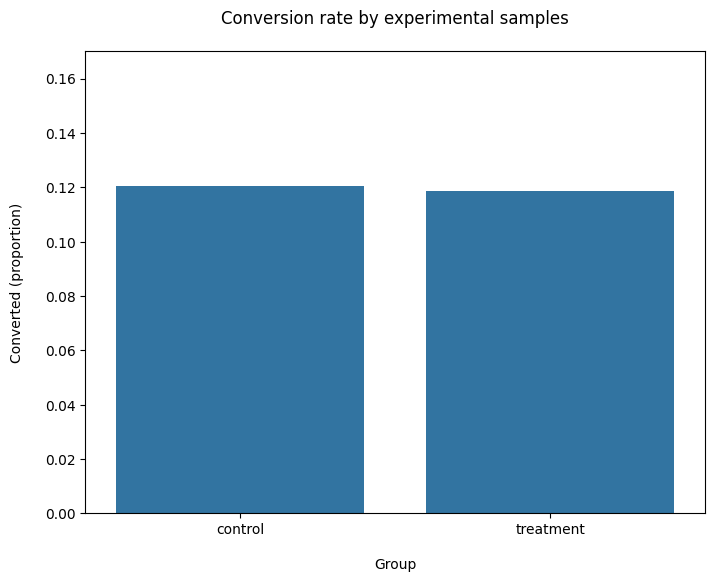

In [9]:
plt.figure(figsize=(8,6));
sns.barplot(x=df_clean['group'], y=df_clean['converted'], errorbar=('ci', False));
plt.ylim(0, 0.17);
plt.title('Conversion rate by experimental samples', pad=20)
plt.xlabel('Group', labelpad=15);
plt.ylabel('Converted (proportion)', labelpad=15);

# 3. Тестирование гипотезы

Посколько мы заранее не имеем представления о том, будет ли новый дизайн сайта работать лучше или хуже чем текущий вариант сайта, мы выбираем двусторонний статистический тест Two-Tailed Test.

H0 : p = p0 H : p != p0

где p и p0 означают коэффициенты конверсии между новым и старым вариантами соответственно. Так же необходимо выбрать уровень доверия (confidence level). В нашем случае мы решили что это будет 95%. Имея уровень доверия в 95% необходимо рассчитать показатель альфа, который будет равен (1 - 0.95) для нашего теста = 0.05.

In [15]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
control_results = df_clean[df_clean['group'] == 'control']['converted']
treatment_results = df_clean[df_clean['group'] == 'treatment']['converted']
n_con = control_results.count()
n_treat = treatment_results.count()
successes = [control_results.sum(), treatment_results.sum()]
nobs = [n_con, n_treat]

z_stat, pval = proportions_ztest(successes, nobs=nobs)
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

print(f'Z-statistic: {z_stat:.2f}')
print(f'p-value: {pval:.3f}')
print(f'CI 95% for control group: [{lower_con:.3f}, {upper_con:.3f}]')
print(f'CI 95% for treatment group: [{lower_treat:.3f}, {upper_treat:.3f}]')

Z-statistic: 1.31
p-value: 0.190
CI 95% for control group: [0.119, 0.122]
CI 95% for treatment group: [0.117, 0.120]


Мы не можем отклонить нулевую гипотезу, т.к. p-value = 0.19 > 0.05.

# 4. Тестирование гипотезы по сегментам старых и новых пользователей

Проверим, влияет ли новый алгоритм по-разному на новых (new_user) и старых (registered_user) пользователей.

In [14]:
def check_segment(df, segment_name):
    print(f"Анализ для сегмента {segment_name}")
    data_segment = df[df['user_type'] == segment_name]

    control = data_segment[data_segment['group'] == 'control']['converted']
    treatment = data_segment[data_segment['group'] == 'treatment']['converted']

    nobs = [control.count(), treatment.count()]
    successes = [control.sum(), treatment.sum()]

    z_stat, pval = proportions_ztest(successes, nobs=nobs)

    print(f"Mean Control: {control.mean():.4f}")
    print(f"Mean Treatment: {treatment.mean():.4f}")
    print(f"p-value: {pval:.3f}\n")

check_segment(df_clean, 'new_user')
check_segment(df_clean, 'registered_user')

Анализ для сегмента new_user
Mean Control: 0.1209
Mean Treatment: 0.1173
p-value: 0.036

Анализ для сегмента registered_user
Mean Control: 0.1199
Mean Treatment: 0.1203
p-value: 0.812



Для зарегистрированных пользователей разницы нет (p-value = 0.81). Конверсия на старом и новом сайте одинакова.

Для новых пользователей обнаружено снижение конверсии с 12.1% до 11.7% и это снижение является статистически значимым (p-value = 0.036 < 0.05).

## Вывод:
Тест показал, что новый вариант svm_ensemble_v_1_22 не дает целевого прироста конверсии в 2%, а ухудшает его, особенно для новых пользователей. Рекомендуется оставить старый вариант сайта и исследовать причины снижения конверсии для новых пользователей.

# 4. EDA

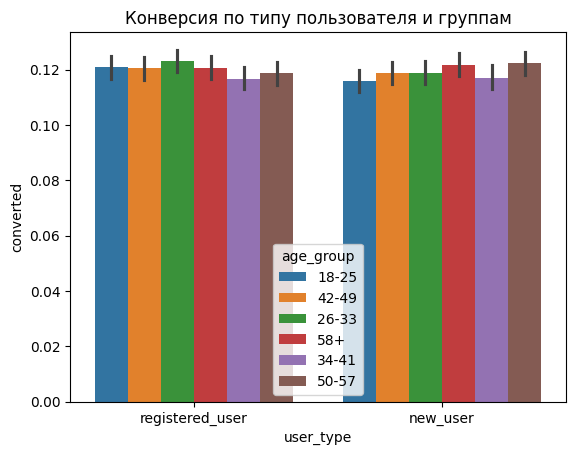

In [12]:
sns.barplot(x='user_type', y='converted', hue='age_group', data=df_clean)
plt.title('Конверсия по типу пользователя и группам')
plt.show()

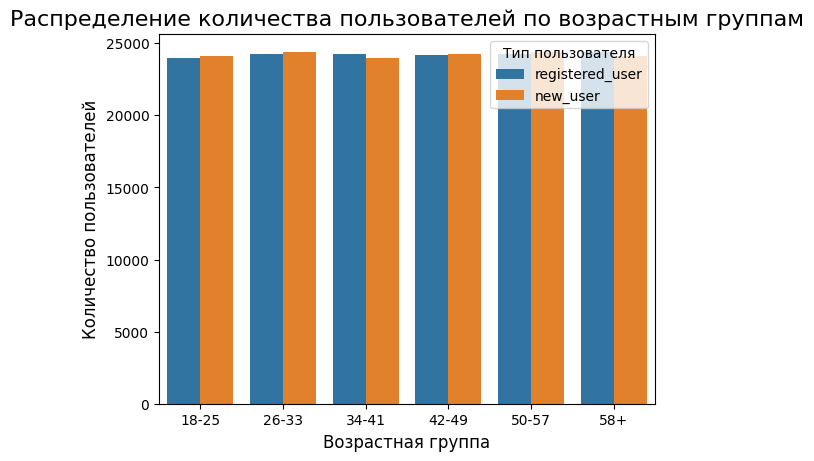

In [13]:
sorted_ages = sorted(df_clean['age_group'].unique())

sns.countplot(
    x='age_group', 
    hue='user_type', 
    data=df_clean, 
    order=sorted_ages
)

plt.title('Распределение количества пользователей по возрастным группам', fontsize=16)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(title='Тип пользователя')
plt.show()